In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


e:\GitHub\dpp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "sshikamaru/car-object-detection" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\car-object-detection' already exists with files. Skipping download (replace=False).


In [3]:
files

['data']

In [4]:
df = pd.read_csv("/".join(["../data/raw/car-object-detection/data/train_solution_bounding_boxes (1).csv"]))
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(559, 5)

'Description'

,count,mean,std,min,25%,50%,75%,max
xmin,559.0,263.39,207.37,0.00,61.39,236.75,446.84,645.18
ymin,559.0,186.52,9.32,148.40,180.11,187.52,193.88,208.06
xmax,559.0,365.32,213.50,28.56,166.31,348.59,571.32,676.00
ymax,559.0,231.50,13.99,198.32,223.23,230.56,237.90,308.32


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
image,object,0,355,"[vid_4_9760.jpg, vid_4_21480.jpg, vid_4_9060.jpg]"
xmin,float64,0,440,"[417.2416787, 183.4298119, 2.93487699]"
ymin,float64,0,149,"[204.720693, 168.4507722, 181.585978]"
xmax,float64,0,438,"[256.8017366, 61.63241679, 56.12818645]"
ymax,float64,0,184,"[238.1921956, 217.8458816, 233.4958172]"


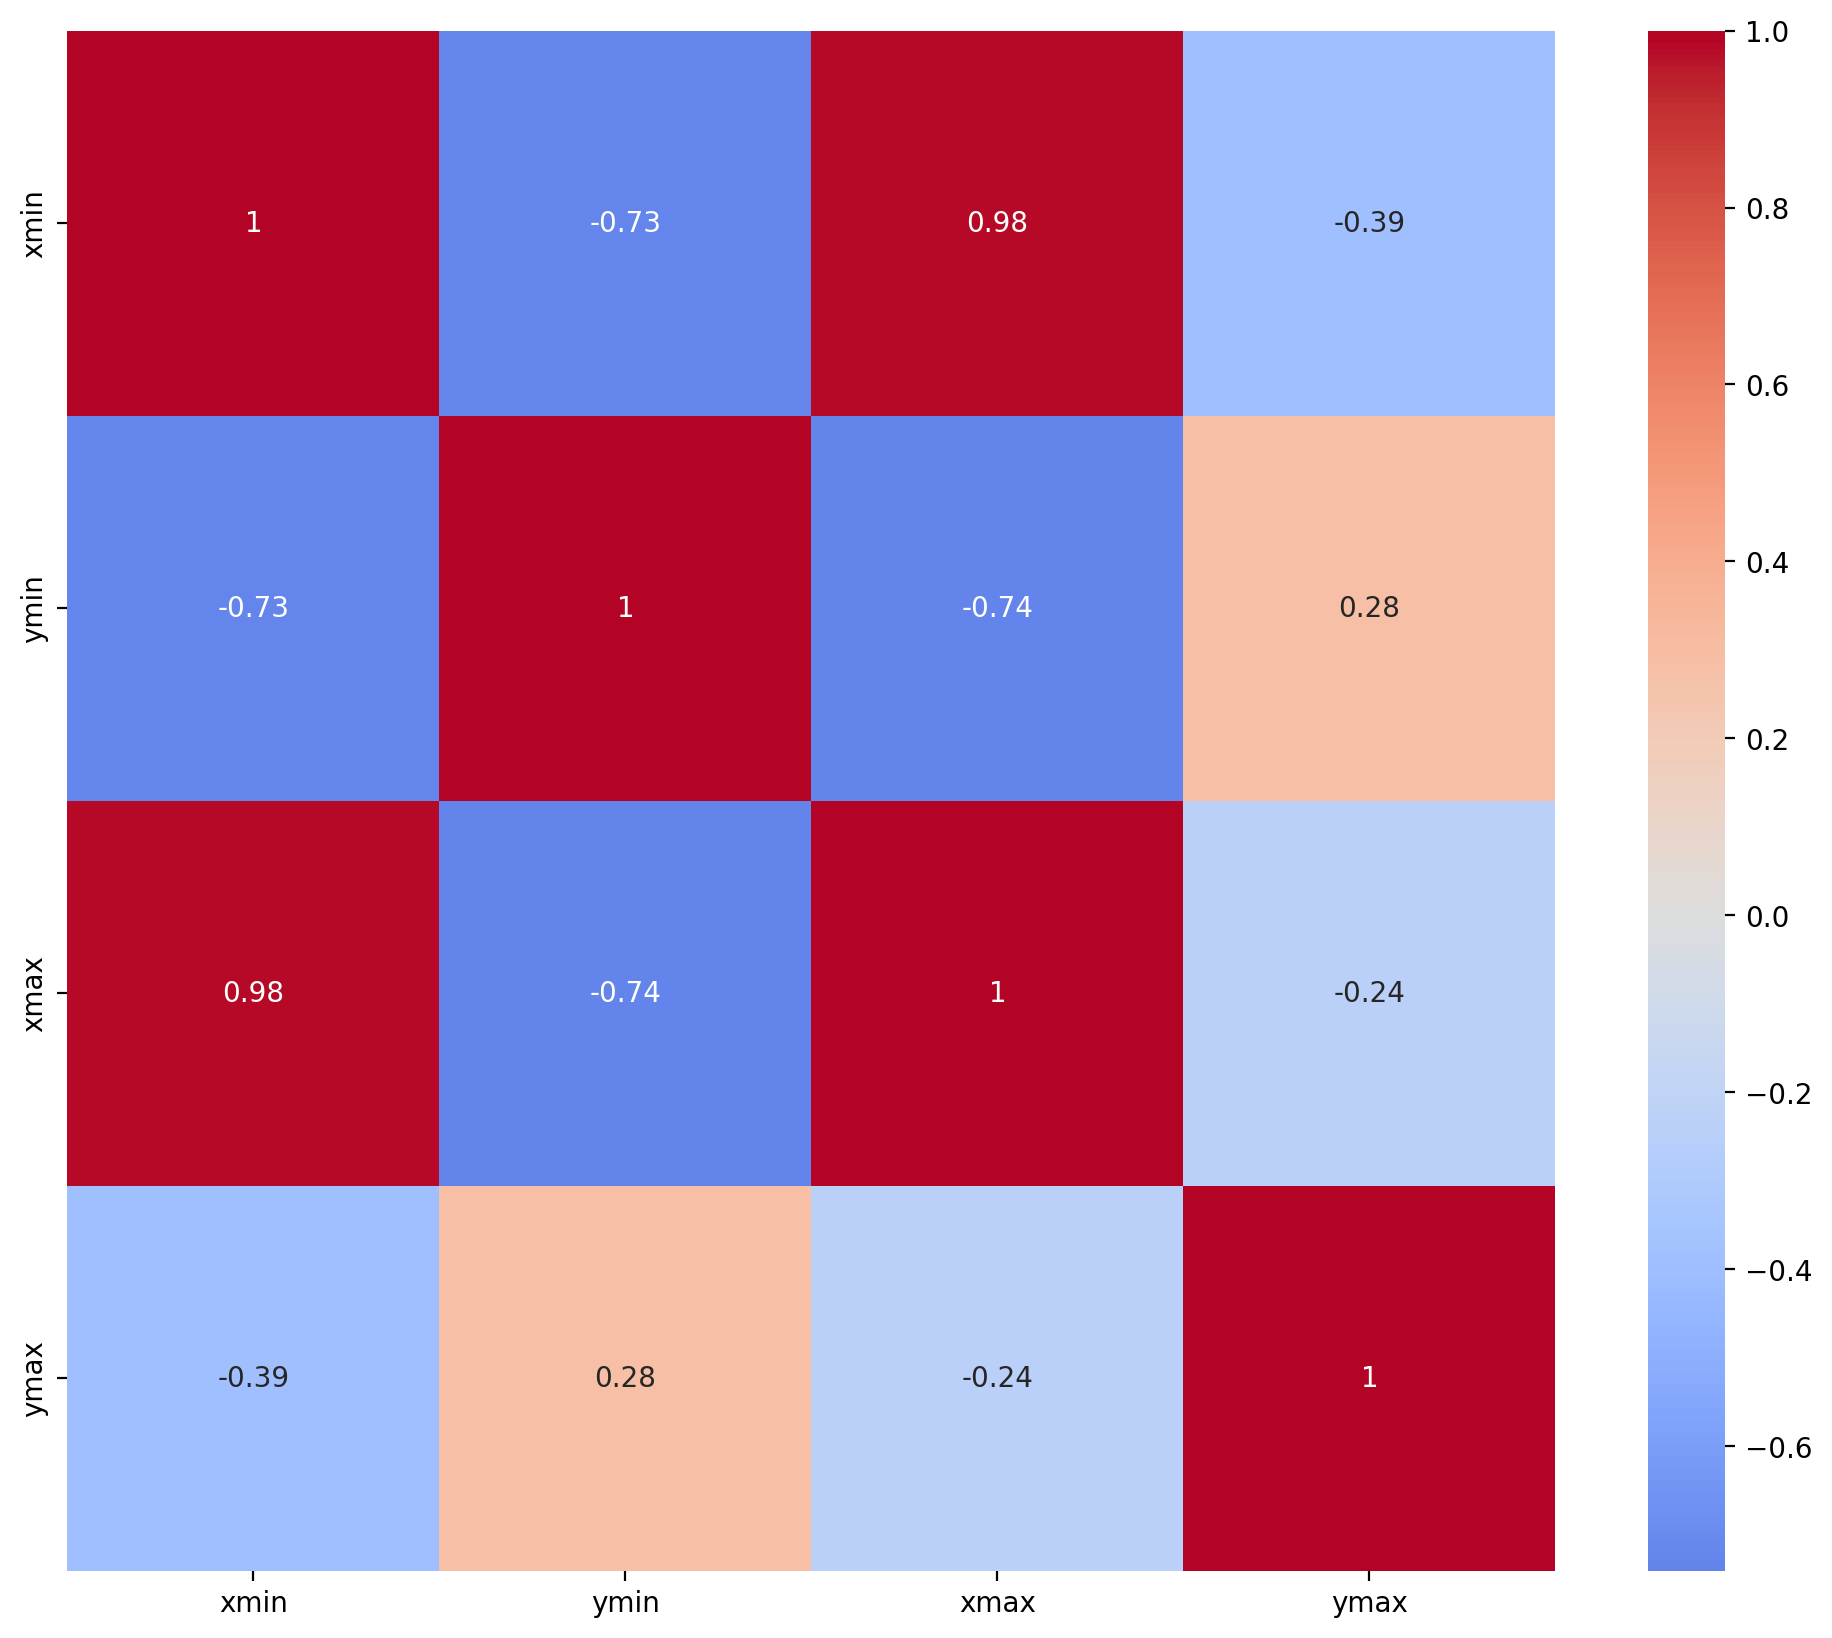

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

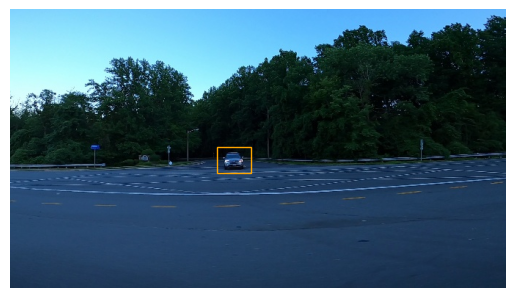

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

img = plt.imread("../data/raw/car-object-detection/data/training_images/vid_4_1000.jpg")

fig, ax = plt.subplots()
ax.imshow(img)

points = [
    (281.259045, 187.035071),
    (327.727931, 187.035071),
    (327.727931, 223.225547),
    (281.259045, 223.225547),
]

square = Polygon(
    points,
    closed=True,
    fill=False,
    edgecolor="orange",
    linewidth=1
)

ax.add_patch(square)
ax.axis("off")
plt.show()

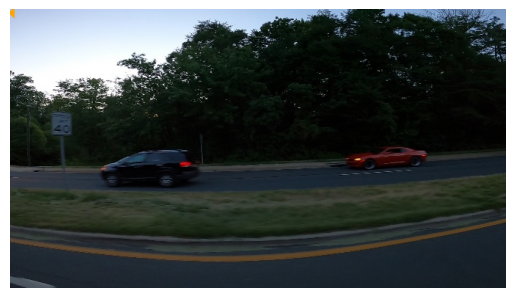

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

img = plt.imread("../data/raw/car-object-detection/data/testing_images/vid_5_26920.jpg")

fig, ax = plt.subplots()
ax.imshow(img)

points = [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1),
]

square = Polygon(
    points,
    closed=True,
    fill=False,
    edgecolor="orange",
    linewidth=5
)

ax.add_patch(square)
ax.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Miche\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
from ast import mod


model_n = YOLO(model='yolov8n.pt')
model_m = YOLO(model='yolov8m.pt')

print(model_n)
print(model_m)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [14]:
from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(df.iloc[:,1:],
                                                                            df.iloc[:,0],
                                                                            test_size=0.1,
                                                                            random_state=42)

print(features_train)

           xmin        ymin        xmax        ymax
460  415.774240  180.188224  528.767004  223.225547
235  605.073806  176.275740  676.000000  218.334942
228    0.489146  196.816281   63.589001  227.627091
290  260.225760  196.816281  378.599132  236.919241
487  358.924982  187.984942  432.285506  220.964216
..          ...         ...         ...         ...
71     0.000000  195.349099  130.112880  252.080116
106    0.000000  194.860039  161.907381  279.956564
270   75.817656  196.816281  229.898697  250.612934
435  510.668596  185.567889  622.193922  224.203668
102   64.078148  191.436615  216.202605  246.700450

[503 rows x 4 columns]
